## Analysis Summary -- Ready for Research Team

### By:
MGO

### Date:
2026-03-27

### Description:

Pre-processed analysis outputs with visualizations -- ready for the research track
to interpret and write analytical insight briefs. This notebook produces tables and
charts that the Domain Lead can use directly in reports.

**Output:** `data/06_reporting/` (CSVs) and `data/06_reporting/figures/` (PNG/HTML charts)

## Import libraries

In [1]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

# Add src to path for importing project utilities
sys.path.insert(0, str(Path("../../src").resolve()))

sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Output directories
data_dir = Path("../../data")
reporting_dir = data_dir / "06_reporting"
figures_dir = reporting_dir / "figures"
reporting_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

## Load enriched data

In [2]:
enriched_path = data_dir / "04_enriched" / "posts_with_sentiment.parquet"
intermediate_path = data_dir / "02_intermediate" / "all_posts_cleaned.parquet"
sample_path = data_dir / "sample" / "sample_posts.json"

if enriched_path.exists():
    df = pd.read_parquet(enriched_path)
    print(f"Loaded enriched data: {len(df)} posts")
elif intermediate_path.exists():
    df = pd.read_parquet(intermediate_path)
    print(f"Loaded intermediate data: {len(df)} posts (NLP not yet applied)")
elif sample_path.exists():
    with open(sample_path) as f:
        df = pd.DataFrame(json.load(f))
    print(f"Loaded sample data: {len(df)} posts (demonstration mode)")
else:
    df = pd.DataFrame()
    print("No data available -- run collection and analysis notebooks first")

if not df.empty:
    df["timestamp"] = pd.to_datetime(df.get("timestamp"), errors="coerce")
    print(f"Columns: {df.columns.tolist()}")

Loaded enriched data: 25 posts
Columns: ['id', 'text', 'source', 'platform', 'author', 'timestamp', 'url', 'sentiment_label', 'prob_pos', 'prob_neg', 'prob_neu']


## Sentiment Analysis Summary

In [3]:
has_sentiment = "sentiment_label" in df.columns if not df.empty else False

if has_sentiment:
    # Overall sentiment distribution (plotly pie chart)
    sentiment_counts = df["sentiment_label"].value_counts().reset_index()
    sentiment_counts.columns = ["Sentiment", "Count"]
    fig = px.pie(
        sentiment_counts,
        values="Count",
        names="Sentiment",
        title="Overall Sentiment Distribution",
        color="Sentiment",
        color_discrete_map={"POS": "#2ecc71", "NEG": "#e74c3c", "NEU": "#95a5a6"},
    )
    fig.show()
    fig.write_html(str(figures_dir / "sentiment_distribution.html"))
    fig.write_image(str(figures_dir / "sentiment_distribution.png"), scale=2)
else:
    print("Sentiment labels not available -- run sentiment analysis notebook first")
    print("(notebooks/3-analysis/01_mgo_sentiment_analysis_20260324.ipynb)")

In [4]:
if has_sentiment and "platform" in df.columns:
    # Sentiment by platform (grouped bar chart)
    platform_sentiment = (
        pd.crosstab(df["platform"], df["sentiment_label"], normalize="index").round(3) * 100
    )

    fig = px.bar(
        platform_sentiment.reset_index().melt(id_vars="platform"),
        x="platform",
        y="value",
        color="sentiment_label",
        barmode="group",
        title="Sentiment Distribution by Platform (%)",
        labels={"value": "Percentage", "platform": "Platform", "sentiment_label": "Sentiment"},
        color_discrete_map={"POS": "#2ecc71", "NEG": "#e74c3c", "NEU": "#95a5a6"},
    )
    fig.show()
    fig.write_html(str(figures_dir / "sentiment_by_platform.html"))

    # Export
    platform_sentiment.to_csv(reporting_dir / "sentiment_by_platform.csv")
    print("Exported sentiment_by_platform.csv")

Exported sentiment_by_platform.csv


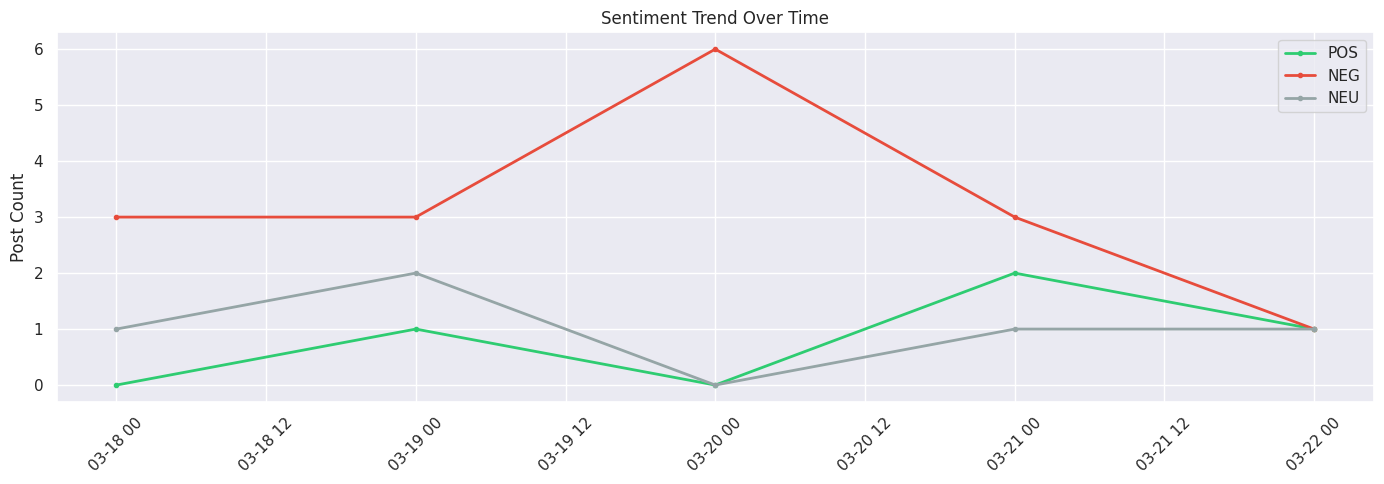

Exported sentiment_trends.csv


In [5]:
if has_sentiment and "timestamp" in df.columns:
    # Sentiment trend over time (line chart)
    df_time = df.dropna(subset=["timestamp"]).copy()
    df_time["date"] = df_time["timestamp"].dt.date

    daily_sentiment = (
        df_time.groupby(["date", "sentiment_label"]).size().unstack(fill_value=0).reset_index()
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    for col in ["POS", "NEG", "NEU"]:
        if col in daily_sentiment.columns:
            color = {"POS": "#2ecc71", "NEG": "#e74c3c", "NEU": "#95a5a6"}.get(col, "gray")
            ax.plot(
                daily_sentiment["date"],
                daily_sentiment[col],
                label=col,
                marker=".",
                linewidth=2,
                color=color,
            )
    ax.set_title("Sentiment Trend Over Time")
    ax.set_ylabel("Post Count")
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(figures_dir / "sentiment_trends.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Export
    daily_sentiment.to_csv(reporting_dir / "sentiment_trends.csv", index=False)
    print("Exported sentiment_trends.csv")

In [6]:
if has_sentiment and "prob_neg" in df.columns:
    # Top 10 most negative posts
    top_negative = df.nlargest(10, "prob_neg")[
        ["text", "source", "platform", "prob_neg", "sentiment_label"]
    ].copy()
    top_negative["text"] = top_negative["text"].str[:150] + "..."
    print("Top 10 Most Negative Posts:")
    display(top_negative)

    # Top 10 most positive posts
    top_positive = df.nlargest(10, "prob_pos")[
        ["text", "source", "platform", "prob_pos", "sentiment_label"]
    ].copy()
    top_positive["text"] = top_positive["text"].str[:150] + "..."
    print("\nTop 10 Most Positive Posts:")
    display(top_positive)

Top 10 Most Negative Posts:


,text,source,platform,prob_neg,sentiment_label
6,"Gonorrea, este gobierno mamerto nos tiene jodi...",Pulzo,rss,0.965250,NEG
17,A mi me da igual quien gane. Todos prometen lo...,Pulzo,rss,0.947743,NEG
2,"Parcero, ustedes creen que las elecciones van ...",La Silla Vacia,rss,0.946094,NEG
3,Las bodegas digitales del uribismo estan traba...,La Silla Vacia,rss,0.937962,NEG
15,Francia Marquez denuncia estigmatizacion: 'Me ...,El Espectador,rss,0.937202,NEG
16,El ESMAD reprime manifestacion pacifica de est...,Blu Radio,rss,0.919584,NEG
4,"Asesinan a lider social en Tumaco, Narino. Es ...",El Tiempo,rss,0.847506,NEG
11,Maria Fernanda Cabal: 'Petro quiere convertir ...,La Silla Vacia,rss,0.798718,NEG
20,ACLED reporta 156 eventos de violencia politic...,gdelt,gdelt,0.793424,NEG
12,Ojo con la compra de votos en la costa. Ya emp...,El Tiempo,rss,0.789976,NEG



Top 10 Most Positive Posts:


,text,source,platform,prob_pos,sentiment_label
5,La paz total de Petro es una chimba de idea. P...,Razon Publica,rss,0.920540,POS
24,Que chimba que la juventud colombiana se este ...,Pulzo,rss,0.822824,POS
18,Gustavo Bolivar confirma que sera candidato pr...,El Tiempo,rss,0.671263,POS
19,German Vargas Lleras mueve su maquinaria en Ca...,La Silla Vacia,rss,0.581415,POS
21,Los trolls inundaron las redes sociales. Todo ...,El Espectador,rss,0.213808,NEU
8,La Registraduria confirma que las elecciones l...,Caracol Radio,rss,0.190885,NEU
22,Debate presidencial en CityTV: Fajardo propone...,Caracol Radio,rss,0.173363,NEU
13,Sergio Fajardo propone pacto nacional por la e...,Razon Publica,rss,0.079181,NEG
1,Fico Gutierrez anuncia su candidatura presiden...,El Espectador,rss,0.071796,NEU
7,"Encuesta Invamer: Fico Gutierrez 28%, Sergio F...",Semana,rss,0.071263,NEU


## Entity Analysis Summary

In [7]:
has_entities = "entities" in df.columns if not df.empty else False

if has_entities:
    # Extract all entities
    all_entities = []
    for entities in df["entities"].dropna():
        if isinstance(entities, list):
            for ent in entities:
                name = ent if isinstance(ent, str) else ent.get("text", "")
                label = "UNKNOWN" if isinstance(ent, str) else ent.get("label", "UNKNOWN")
                if name:
                    all_entities.append({"entity": name, "label": label})

    df_entities = pd.DataFrame(all_entities)
    entity_freq = df_entities["entity"].value_counts().head(20)

    # Most mentioned entities (horizontal bar chart)
    fig, ax = plt.subplots(figsize=(12, 8))
    entity_freq.plot(kind="barh", ax=ax, color="steelblue")
    ax.set_title("Top 20 Most Mentioned Entities")
    ax.set_xlabel("Mentions")
    plt.tight_layout()
    plt.savefig(figures_dir / "entity_frequency.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Export
    entity_freq.to_csv(reporting_dir / "entity_frequency.csv")
    print(f"Exported entity_frequency.csv ({len(entity_freq)} entities)")
else:
    print("Entity data not available -- run NER notebook first")
    print("(notebooks/3-analysis/02_mgo_entity_extraction_20260325.ipynb)")

Entity data not available -- run NER notebook first
(notebooks/3-analysis/02_mgo_entity_extraction_20260325.ipynb)


In [8]:
if has_entities:
    # Co-occurrence matrix: which entities are mentioned together?
    top_entities = entity_freq.head(15).index.tolist()
    cooccurrence = pd.DataFrame(0, index=top_entities, columns=top_entities)

    for entities in df["entities"].dropna():
        if isinstance(entities, list):
            names = [(e if isinstance(e, str) else e.get("text", "")) for e in entities]
            names_in_top = [n for n in names if n in top_entities]
            for i, a in enumerate(names_in_top):
                for b in names_in_top[i + 1 :]:
                    cooccurrence.loc[a, b] += 1
                    cooccurrence.loc[b, a] += 1

    # Heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    sns.heatmap(cooccurrence, annot=True, fmt="d", cmap="YlOrRd", ax=ax)
    ax.set_title("Entity Co-occurrence Matrix")
    plt.tight_layout()
    plt.savefig(figures_dir / "entity_cooccurrence.png", dpi=150, bbox_inches="tight")
    plt.show()

    # Export
    cooccurrence.to_csv(reporting_dir / "entity_cooccurrence.csv")
    print("Exported entity_cooccurrence.csv")

## Narrative / Topic Analysis Summary

In [9]:
has_topics = "topic_id" in df.columns if not df.empty else False

if has_topics:
    # Topic clusters with representative keywords
    topic_summary = (
        df.groupby(["topic_id", "topic_label"])
        .agg(post_count=("id", "count"))
        .reset_index()
        .sort_values("post_count", ascending=False)
    )
    print("Topic clusters:")
    display(topic_summary)

    # Topic distribution (bar chart)
    fig = px.bar(
        topic_summary.head(15),
        x="topic_label",
        y="post_count",
        title="Topic Distribution (Top 15)",
        labels={"post_count": "Number of Posts", "topic_label": "Topic"},
    )
    fig.update_layout(xaxis_tickangle=-45)
    fig.show()
    fig.write_html(str(figures_dir / "topic_distribution.html"))

    # Export
    topic_summary.to_csv(reporting_dir / "topics_summary.csv", index=False)
    print("Exported topics_summary.csv")
else:
    print("Topic data not available -- run topic modeling notebook first")
    print("(notebooks/3-analysis/03_mgo_narrative_topics_20260325.ipynb)")

Topic data not available -- run topic modeling notebook first
(notebooks/3-analysis/03_mgo_narrative_topics_20260325.ipynb)


In [10]:
if has_topics and "timestamp" in df.columns:
    # Topic evolution over time (area chart)
    df_topics_time = df.dropna(subset=["timestamp"]).copy()
    df_topics_time["date"] = df_topics_time["timestamp"].dt.date

    # Get top 5 topics for readability
    top_topics = df_topics_time["topic_label"].value_counts().head(5).index.tolist()
    df_top_topics = df_topics_time[df_topics_time["topic_label"].isin(top_topics)]

    topic_evolution = (
        df_top_topics.groupby(["date", "topic_label"]).size().unstack(fill_value=0).reset_index()
    )

    fig = px.area(
        topic_evolution.melt(id_vars="date"),
        x="date",
        y="value",
        color="topic_label",
        title="Topic Evolution Over Time (Top 5)",
        labels={"value": "Post Count", "date": "Date", "topic_label": "Topic"},
    )
    fig.show()
    fig.write_html(str(figures_dir / "topic_evolution.html"))

    # Export
    topic_evolution.to_csv(reporting_dir / "topic_evolution.csv", index=False)
    print("Exported topic_evolution.csv")

In [11]:
if has_topics:
    # Sample posts per topic (3-5 examples each)
    print("Sample posts per topic:")
    print("=" * 60)
    for topic_label in df["topic_label"].value_counts().head(5).index:
        print(f"\nTopic: {topic_label}")
        print("-" * 40)
        samples = df[df["topic_label"] == topic_label]["text"].head(3)
        for i, text in enumerate(samples, 1):
            print(f"  {i}. {text[:120]}...")

## Geographic Context (ACLED overlay)

In [12]:
# Load ACLED events if available
acled_dir = data_dir / "01_raw" / "acled"
df_acled = pd.DataFrame()

if acled_dir.exists():
    acled_files = sorted(acled_dir.glob("*.json"))
    if acled_files:
        acled_data = []
        for f in acled_files:
            with open(f) as fh:
                acled_data.extend(json.load(fh))
        if acled_data:
            df_acled = pd.DataFrame(acled_data)
            print(f"Loaded {len(df_acled)} ACLED events")

if not df_acled.empty:
    # ACLED events timeline
    print("\nACLED Events Timeline for Colombia:")
    print("=" * 60)
    for _, event in df_acled.iterrows():
        fatalities_marker = (
            f" [{event.get('fatalities', 0)} fatalities]" if event.get("fatalities", 0) > 0 else ""
        )
        print(
            f"  {event['event_date']} | {event['event_type']} | {event.get('location', 'N/A')}{fatalities_marker}"
        )
        print(f"    {event.get('notes', '')[:100]}")

    # Events by department (simple table)
    if "admin1" in df_acled.columns:
        print("\nEvents by department:")
        dept_counts = df_acled["admin1"].value_counts()
        display(dept_counts.to_frame("event_count"))

    # Export filtered ACLED events
    acled_csv = reporting_dir / "acled_events_filtered.csv"
    df_acled.to_csv(acled_csv, index=False, encoding="utf-8")
    print("\nExported acled_events_filtered.csv")
else:
    print("No ACLED data available -- run GDELT/ACLED collection notebook first")
    print("(notebooks/1-data/03_mgo_gdelt_acled_collection_20260323.ipynb)")

No ACLED data available -- run GDELT/ACLED collection notebook first
(notebooks/1-data/03_mgo_gdelt_acled_collection_20260323.ipynb)


In [13]:
# Correlation: do online sentiment shifts correspond to real-world events?
if has_sentiment and not df_acled.empty:
    print("Sentiment-Event Correlation Analysis:")
    print("=" * 60)

    # Get daily sentiment scores
    df_daily = df.dropna(subset=["timestamp"]).copy()
    df_daily["date"] = df_daily["timestamp"].dt.strftime("%Y-%m-%d")

    daily_neg_pct = (
        df_daily.groupby("date")["sentiment_label"]
        .apply(lambda x: (x == "NEG").sum() / len(x) * 100)
        .reset_index()
    )
    daily_neg_pct.columns = ["date", "neg_pct"]

    # Check ACLED event dates
    acled_dates = set(df_acled["event_date"].unique())
    daily_neg_pct["acled_event"] = daily_neg_pct["date"].isin(acled_dates)

    print("\nDays with ACLED events vs sentiment:")
    for _, row in daily_neg_pct[daily_neg_pct["acled_event"]].iterrows():
        events_that_day = df_acled[df_acled["event_date"] == row["date"]]
        event_desc = (
            events_that_day.iloc[0].get("notes", "")[:80] if len(events_that_day) > 0 else ""
        )
        print(f"  {row['date']}: {row['neg_pct']:.1f}% negative sentiment | ACLED: {event_desc}")
else:
    print("Cannot compute correlation -- need both sentiment data and ACLED events")

Cannot compute correlation -- need both sentiment data and ACLED events


## Key Findings for Research Team

Bullet-point summary of quantitative findings. These are **DATA findings**, not
interpretations -- the Domain Lead adds political and contextual analysis.

In [14]:
print("KEY QUANTITATIVE FINDINGS")
print("=" * 60)

if not df.empty:
    print(f"\n1. CORPUS: {len(df)} posts collected from {df['platform'].nunique()} platforms")

    if has_sentiment:
        neg_pct = (df["sentiment_label"] == "NEG").sum() / len(df) * 100
        pos_pct = (df["sentiment_label"] == "POS").sum() / len(df) * 100
        print(f"\n2. SENTIMENT: {neg_pct:.1f}% negative, {pos_pct:.1f}% positive overall")

        if "platform" in df.columns:
            for platform in df["platform"].unique():
                platform_df = df[df["platform"] == platform]
                platform_neg = (
                    (platform_df["sentiment_label"] == "NEG").sum() / len(platform_df) * 100
                )
                print(f"   - {platform}: {platform_neg:.1f}% negative")

    if has_topics:
        top_topic = df["topic_label"].value_counts().index[0]
        top_topic_pct = df["topic_label"].value_counts().iloc[0] / len(df) * 100
        print(f"\n3. TOPICS: '{top_topic}' dominates with {top_topic_pct:.1f}% of discourse")

    if not df_acled.empty:
        print(f"\n4. CONTEXT: {len(df_acled)} ACLED events during collection period")
        if "fatalities" in df_acled.columns:
            print(f"   - Total fatalities: {df_acled['fatalities'].sum()}")

print("\n" + "=" * 60)
print("NOTE: These are quantitative findings. The Domain Lead adds")
print("political context and interprets significance for CIVICUS.")

KEY QUANTITATIVE FINDINGS

1. CORPUS: 25 posts collected from 2 platforms

2. SENTIMENT: 64.0% negative, 16.0% positive overall
   - rss: 62.5% negative
   - gdelt: 100.0% negative

NOTE: These are quantitative findings. The Domain Lead adds
political context and interprets significance for CIVICUS.


## Signal-Insight-Action Template

Template showing the format CIVICUS expects for analytical insight briefs.
The Data Analyst (MGO) fills in the **Signal**; the Domain Lead fills in
**Insight**, **Action**, and **Outcome**.

In [15]:
template = """
========================================
SIGNAL-INSIGHT-ACTION TEMPLATE
========================================

SIGNAL 1:
  Signal:  [What changed in the data? -- Data Analyst fills this]
  Insight: [Why does it matter? -- Domain Lead fills this]
  Action:  [What should stakeholders do? -- Domain Lead fills this]
  Outcome: [How to measure success? -- Domain Lead fills this]

EXAMPLE (filled):
  Signal:  Negative sentiment toward electoral institutions spiked 40%
           on March 25, concentrated on RSS sources
  Insight: [Domain Lead]: This coincides with the CNE ruling on candidate
           eligibility. Delegitimization of electoral bodies is a known
           precursor to democratic backsliding in Latin America.
  Action:  [Domain Lead]: Monitor for coordinated amplification. Alert
           CIVICUS early warning network if spike persists >72 hours.
  Outcome: Sentiment returns to baseline within 1 week; no evidence
           of coordinated inauthentic behavior detected.

========================================

SIGNAL 2:
  Signal:  [What changed in the data?]
  Insight: [Why does it matter? -- Domain Lead]
  Action:  [What should stakeholders do? -- Domain Lead]
  Outcome: [How to measure success? -- Domain Lead]

SIGNAL 3:
  Signal:  [What changed in the data?]
  Insight: [Why does it matter? -- Domain Lead]
  Action:  [What should stakeholders do? -- Domain Lead]
  Outcome: [How to measure success? -- Domain Lead]
"""
print(template)

# Save template
template_path = reporting_dir / "signal_insight_action_template.txt"
with open(template_path, "w", encoding="utf-8") as f:
    f.write(template)
print(f"Saved template to {template_path}")


SIGNAL-INSIGHT-ACTION TEMPLATE

SIGNAL 1:
  Signal:  [What changed in the data? -- Data Analyst fills this]
  Insight: [Why does it matter? -- Domain Lead fills this]
  Action:  [What should stakeholders do? -- Domain Lead fills this]
  Outcome: [How to measure success? -- Domain Lead fills this]

EXAMPLE (filled):
  Signal:  Negative sentiment toward electoral institutions spiked 40%
           on March 25, concentrated on RSS sources
  Insight: [Domain Lead]: This coincides with the CNE ruling on candidate
           eligibility. Delegitimization of electoral bodies is a known
           precursor to democratic backsliding in Latin America.
  Action:  [Domain Lead]: Monitor for coordinated amplification. Alert
           CIVICUS early warning network if spike persists >72 hours.
  Outcome: Sentiment returns to baseline within 1 week; no evidence
           of coordinated inauthentic behavior detected.


SIGNAL 2:
  Signal:  [What changed in the data?]
  Insight: [Why does it matter?

## Export All Outputs

In [16]:
# Generate manifest of all exported files
all_exports = []
for f in sorted(reporting_dir.glob("*.csv")):
    all_exports.append(
        {"file": f.name, "type": "CSV", "size_kb": round(f.stat().st_size / 1024, 1)}
    )
for f in sorted(figures_dir.glob("*")):
    all_exports.append(
        {
            "file": f"figures/{f.name}",
            "type": f.suffix.upper(),
            "size_kb": round(f.stat().st_size / 1024, 1),
        }
    )
for f in sorted(reporting_dir.glob("*.txt")):
    all_exports.append(
        {"file": f.name, "type": "TXT", "size_kb": round(f.stat().st_size / 1024, 1)}
    )
for f in sorted(reporting_dir.glob("*.md")):
    all_exports.append({"file": f.name, "type": "MD", "size_kb": round(f.stat().st_size / 1024, 1)})

manifest = {
    "project": "Pulso Electoral Colombia 2026",
    "notebook": "02_mgo_analysis_summary_20260327",
    "description": "Analysis summary outputs for CIVICUS DDI research team",
    "files": all_exports,
}

manifest_path = reporting_dir / "analysis_manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2, default=str)

print("All exported files:")
print("=" * 60)
for item in all_exports:
    print(f"  {item['file']} ({item['type']}, {item['size_kb']} KB)")
print(f"\nManifest saved to {manifest_path}")

All exported files:
  pulso_electoral_main_dataset.csv (CSV, 8.7 KB)
  sentiment_by_platform.csv (CSV, 0.1 KB)
  sentiment_trends.csv (CSV, 0.1 KB)
  figures/sentiment_by_platform.html (.HTML, 4742.6 KB)
  figures/sentiment_distribution.html (.HTML, 4741.5 KB)
  figures/sentiment_distribution.png (.PNG, 72.8 KB)
  figures/sentiment_trends.png (.PNG, 96.0 KB)
  signal_insight_action_template.txt (TXT, 1.4 KB)
  METHODOLOGY.md (MD, 1.8 KB)

Manifest saved to ../../data/06_reporting/analysis_manifest.json


## References

- Plotly visualization library: https://plotly.com/python/
- Seaborn: https://seaborn.pydata.org/
- CIVICUS Digital Democracy Initiative: https://civicus.org
- pysentimiento: https://github.com/pysentimiento/pysentimiento
- ACLED: https://acleddata.com